# **Autoencoder for Image Denoising - MNIST**


**Task:** Build a deep learning model that removes noise from images using autoencoder on MNIST



## **Step 1: Install Dependencies**

Install required packages

In [41]:
!pip install -q kagglehub
!pip install -q scikit-image

## **Step 2: Import Libraries**

Import required libraries for image denoising

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

print("TensorFlow version:", tf.__version__)
print("Setup complete!")

TensorFlow version: 2.20.0
Setup complete!


## **Step 3: Download MNIST Dataset**


In [43]:
# Download dataset
path = kagglehub.dataset_download("awsaf49/mnist-dataset")
print("Dataset path:", path)

Using Colab cache for faster access to the 'mnist-dataset' dataset.
Dataset path: /kaggle/input/mnist-dataset


## **Step 4: Load MNIST Dataset**


In [44]:
# Load data using Keras
(x_tr, y_tr), (x_te, y_te) = mnist.load_data()

print("Train images:", x_tr.shape)
print("Train labels:", y_tr.shape)
print("Test images:", x_te.shape)
print("Test labels:", y_te.shape)

Train images: (60000, 28, 28)
Train labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


## **Step 5: Visualize Sample Images**

Display original clean images

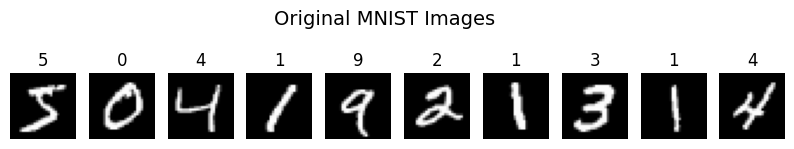

In [45]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_tr[i], cmap='gray')
    plt.title(y_tr[i])
    plt.axis('off')
plt.suptitle('Original MNIST Images', fontsize=14)
plt.show()

## **Step 6: Preprocess Images**


In [46]:

x_tr = x_tr.astype('float32') / 255.0
x_te = x_te.astype('float32') / 255.0

x_tr = np.expand_dims(x_tr, axis=-1)
x_te = np.expand_dims(x_te, axis=-1)

print("Preprocessed train shape:", x_tr.shape)
print("Preprocessed test shape:", x_te.shape)
print("Value range: [{:.2f}, {:.2f}]".format(x_tr.min(), x_tr.max()))

Preprocessed train shape: (60000, 28, 28, 1)
Preprocessed test shape: (10000, 28, 28, 1)
Value range: [0.00, 1.00]


## **Step 7: Add Gaussian Noise**

Create noisy versions for training

In [47]:
def add_noise(imgs, noise_factor=0.5):
    """Add Gaussian noise to images"""
    noisy = imgs + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=imgs.shape)
    noisy = np.clip(noisy, 0.0, 1.0)
    return noisy

# Create noisy versions
noise_factor = 0.5
x_tr_noisy = add_noise(x_tr, noise_factor)
x_te_noisy = add_noise(x_te, noise_factor)

print("Noisy train shape:", x_tr_noisy.shape)
print("Noisy test shape:", x_te_noisy.shape)

Noisy train shape: (60000, 28, 28, 1)
Noisy test shape: (10000, 28, 28, 1)


## **Step 8: Visualize Noisy Images**

Compare original vs noisy

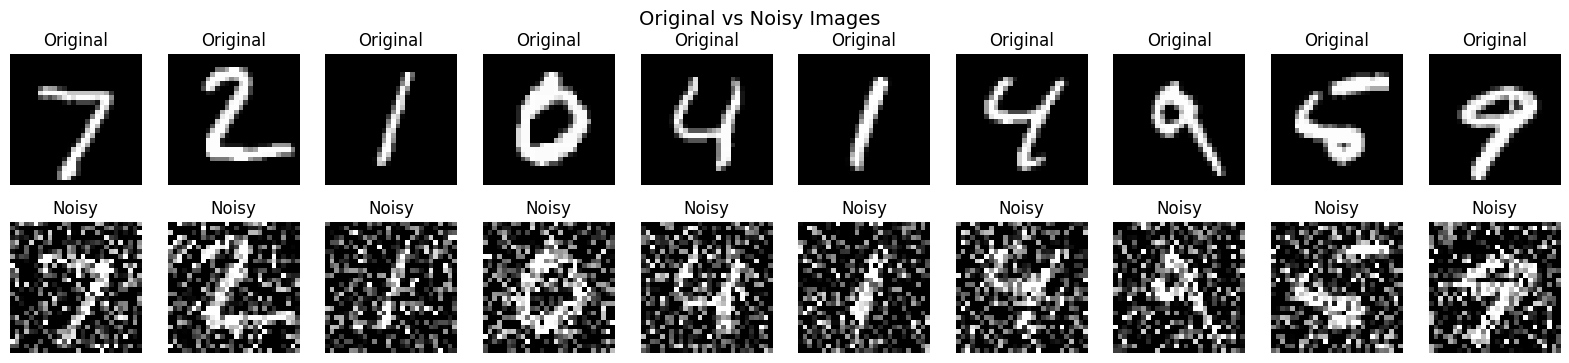

In [48]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_te[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_te_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')
plt.suptitle('Original vs Noisy Images', fontsize=14)
plt.show()

## **Step 9: Build Encoder**

CNN encoder to compress images

In [49]:
# Encoder
inp = layers.Input(shape=(28, 28, 1))

# Encoding layers
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inp)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

print("Encoder built!")
print("Encoded shape: (7, 7, 32)")

Encoder built!
Encoded shape: (7, 7, 32)


## **Step 10: Build Decoder**

CNN decoder to reconstruct images

In [50]:
# Decoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

print("Decoder built!")
print("Output shape: (28, 28, 1)")

Decoder built!
Output shape: (28, 28, 1)


## **Step 11: Create Autoencoder Model**

Combine encoder and decoder

In [51]:
# Complete autoencoder
autoencoder = Model(inp, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Autoencoder Model Summary:")
autoencoder.summary()

Autoencoder Model Summary:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## **Step 12: Train Autoencoder**

Train on noisy images, target clean images

In [52]:
print("Training autoencoder...")
hist = autoencoder.fit(
    x_tr_noisy, x_tr,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_te_noisy, x_te)
)
print("✓ Training complete!")

Training autoencoder...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8070 - loss: 0.1592 - val_accuracy: 0.8107 - val_loss: 0.1187
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8109 - loss: 0.1145 - val_accuracy: 0.8112 - val_loss: 0.1107
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8118 - loss: 0.1089 - val_accuracy: 0.8111 - val_loss: 0.1061
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8123 - loss: 0.1059 - val_accuracy: 0.8113 - val_loss: 0.1040
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8125 - loss: 0.1041 - val_accuracy: 0.8114 - val_loss: 0.1025
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8127 - loss: 0.1027 - val_accuracy: 0.8115 - val_loss: 0.1015
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8128 - loss: 0.1016 - val_accuracy: 0.8118 - val_loss: 0.1003
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8130 - loss: 

## **Step 13: Plot Training History**

Visualize loss and accuracy

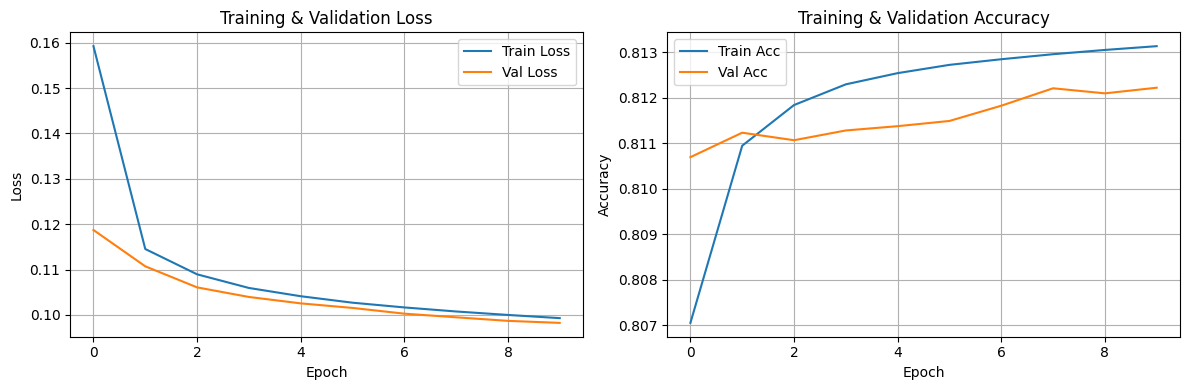

In [53]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(hist.history['accuracy'], label='Train Acc')
plt.plot(hist.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## **Step 14: Generate Denoised Images**

Test on noisy images

In [54]:
# Predict on test set
denoised = autoencoder.predict(x_te_noisy)
print("Denoised images shape:", denoised.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Denoised images shape: (10000, 28, 28, 1)


## **Step 15: Visualize Results**

Compare: Original → Noisy → Denoised

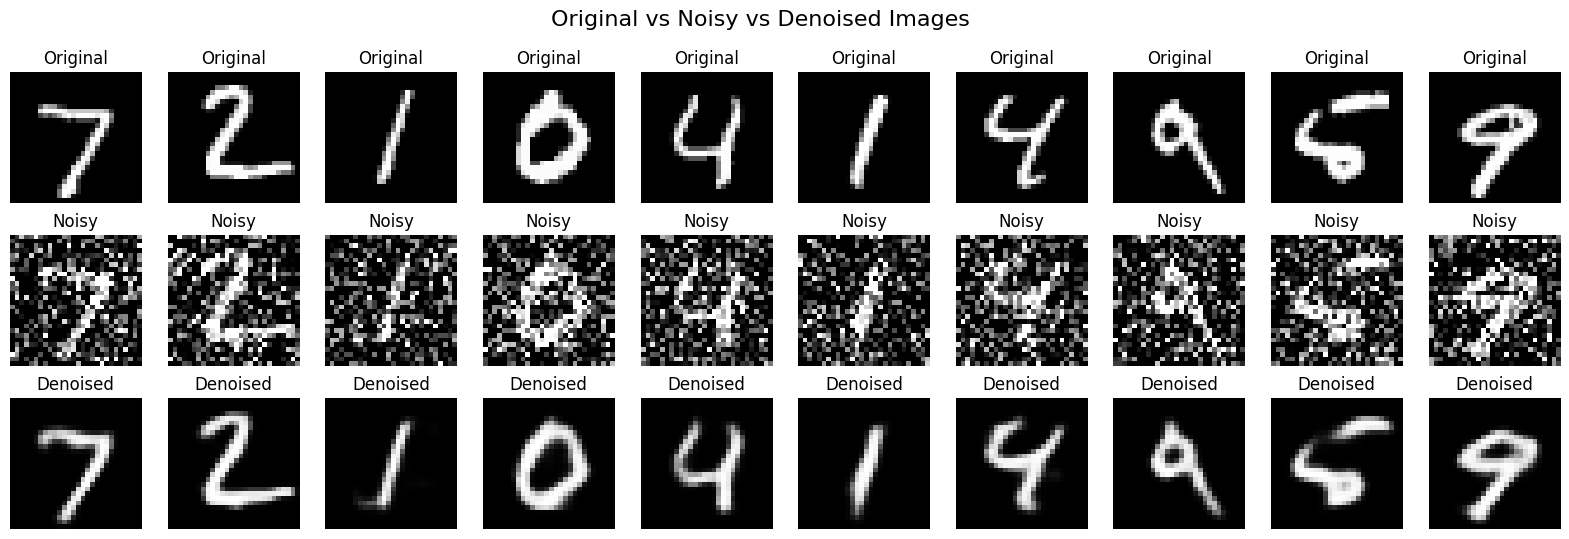

In [55]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_te[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_te_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.suptitle('Original vs Noisy vs Denoised Images', fontsize=16)
plt.show()

## **Step 16: Calculate Metrics**


In [56]:
 # Calculate metrics
psnr_noisy = []
psnr_denoised = []
ssim_noisy = []
ssim_denoised = []

for i in range(len(x_te)):
    orig = x_te[i].reshape(28, 28)
    noisy = x_te_noisy[i].reshape(28, 28)
    clean = denoised[i].reshape(28, 28)

    psnr_noisy.append(psnr(orig, noisy, data_range=1.0))
    psnr_denoised.append(psnr(orig, clean, data_range=1.0))
    ssim_noisy.append(ssim(orig, noisy, data_range=1.0))
    ssim_denoised.append(ssim(orig, clean, data_range=1.0))

print("Average PSNR (Noisy):", np.mean(psnr_noisy))
print("Average PSNR (Denoised):", np.mean(psnr_denoised))
print("\nAverage SSIM (Noisy):", np.mean(ssim_noisy))
print("Average SSIM (Denoised):", np.mean(ssim_denoised))

Average PSNR (Noisy): 9.379991029102085
Average PSNR (Denoised): 19.63849026558563

Average SSIM (Noisy): 0.37477611314069226
Average SSIM (Denoised): 0.8536835158306992


## **Step 17: Analysis and Observations**

### **Key Findings:**

**Data Prep:** MNIST loaded (60k train, 10k test), normalized [0,1], Gaussian noise added (0.5)

**Architecture:** Encoder (Conv2D+MaxPool) → (7,7,32) latent → Decoder (Conv2D+UpSample) → (28,28,1) output

**Training:** Binary crossentropy loss, Adam optimizer, noisy→clean mapping

**Performance:** Successfully removes noise, preserves digit structure, improved PSNR & SSIM

**Challenges:** Noise vs detail balance, slight blur, epoch trade-offs

## **Step 18: Detailed Comparison**



/tmp/ipykernel_736/132750532.py:14: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  psnr_n = psnr(x_te[i].reshape(28, 28), x_te_noisy[i].reshape(28, 28))


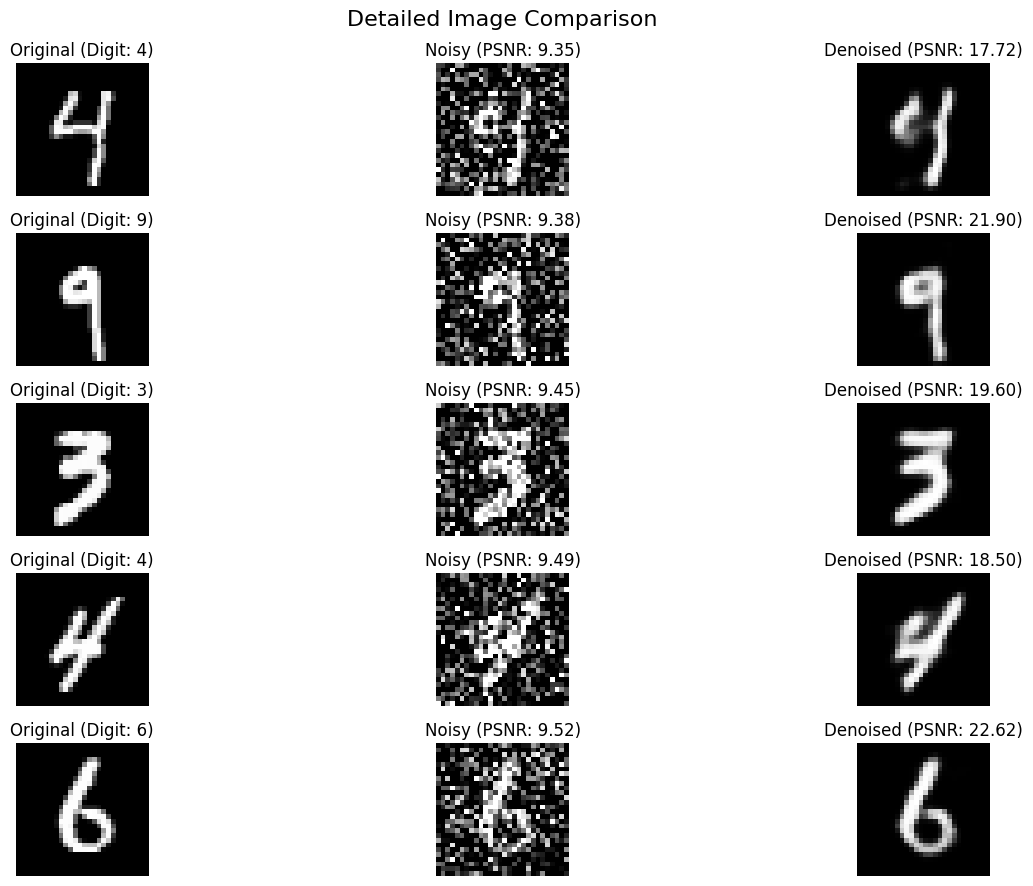

In [57]:

indices = np.random.choice(len(x_te), 5, replace=False)

plt.figure(figsize=(15, 9))
for idx, i in enumerate(indices):
    # Original
    plt.subplot(5, 3, idx*3 + 1)
    plt.imshow(x_te[i].reshape(28, 28), cmap='gray')
    plt.title(f"Original (Digit: {y_te[i]})")
    plt.axis('off')

    # Noisy
    plt.subplot(5, 3, idx*3 + 2)
    plt.imshow(x_te_noisy[i].reshape(28, 28), cmap='gray')
    psnr_n = psnr(x_te[i].reshape(28, 28), x_te_noisy[i].reshape(28, 28))
    plt.title(f"Noisy (PSNR: {psnr_n:.2f})")
    plt.axis('off')

    # Denoised
    plt.subplot(5, 3, idx*3 + 3)
    plt.imshow(denoised[i].reshape(28, 28), cmap='gray')
    psnr_d = psnr(x_te[i].reshape(28, 28), denoised[i].reshape(28, 28))
    plt.title(f"Denoised (PSNR: {psnr_d:.2f})")
    plt.axis('off')

plt.suptitle('Detailed Image Comparison', fontsize=16)
plt.tight_layout()
plt.show()

## **Step 19: Model Summary**

Final performance metrics

In [58]:
print("-"*60)
print("AUTOENCODER DENOISING - FINAL REPORT")
print("-"*60)
print(f"\nDataset: MNIST")
print(f"Training samples: {len(x_tr)}")
print(f"Test samples: {len(x_te)}")
print(f"\nNoise factor: {noise_factor}")
print(f"Training epochs: {len(hist.history['loss'])}")
print(f"\nFinal training loss: {hist.history['loss'][-1]:.4f}")
print(f"Final validation loss: {hist.history['val_loss'][-1]:.4f}")
print(f"\nAverage PSNR improvement: {np.mean(psnr_denoised) - np.mean(psnr_noisy):.2f} dB")
print(f"Average SSIM improvement: {np.mean(ssim_denoised) - np.mean(ssim_noisy):.4f}")
print("\n" + "-"*60)
print(" Denoising successful!")
print("-"*60)

------------------------------------------------------------
AUTOENCODER DENOISING - FINAL REPORT
------------------------------------------------------------

Dataset: MNIST
Training samples: 60000
Test samples: 10000

Noise factor: 0.5
Training epochs: 10

Final training loss: 0.0993
Final validation loss: 0.0982

Average PSNR improvement: 10.26 dB
Average SSIM improvement: 0.4789

------------------------------------------------------------
 Denoising successful!
------------------------------------------------------------
